# EDA – Analyse exploratoire du dataset `Entreprises entites stagiaires.csv`

## 1. Introduction, contexte et objectifs

### 1.1 Origine du fichier

Le fichier `Entreprises entites stagiaires.csv` est un export brut issu du progiciel de gestion académique Aurion. Il centralise plusieurs types d’informations liées aux relations entre l’établissement et les structures externes : identification des entités, adresses, interlocuteurs, informations relatives aux stages, contrats professionnels, apprentissages, ainsi que données liées aux versements de taxe d’apprentissage.

### 1.2 Objectif du notebook

Ce notebook a pour objectif de réaliser une analyse exploratoire des données avant la création de l’ETL du POC2.

L’analyse vise à cartographier le jeu de données, mesurer sa complétude, comprendre sa granularité réelle et identifier les principales anomalies de typage ou de structure avant d’envisager une automatisation de l’import.

### 1.3 Lien avec le POC2

Dans le cadre du POC2, l’objectif est d’intégrer ces données de manière propre et structurée dans MongoDB, puis de rendre une partie de ces informations visible dans CremeCRM.

Ce notebook sert donc de base de travail pour déterminer si le fichier est techniquement et fonctionnellement exploitable, et pour préparer un schéma de transformation adapté aux besoins du CRM.

### 1.4 Rôle de l’EDA avant l’ETL

L’EDA permet d’éviter un import naïf ligne par ligne. Elle sert à identifier les règles de nettoyage et de restructuration nécessaires avant l’écriture du pipeline ETL : gestion des valeurs manquantes, suppression des doublons stricts, conservation des répétitions métier légitimes, conversion des dates et montants, séparation des entités, contacts, adresses et événements.

Cette étape permet donc de faire le lien entre une source brute issue d’Aurion et une future structure de données exploitable dans le cadre du POC2.


## 2. Importation des dépendance

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 3. Chargement du fichier CSV et gestion du préambule

Le fichier contient un préambule correspondant aux critères d’extraction Aurion.  
Les 21 premières lignes doivent être ignorées afin de charger uniquement le tableau de données métier.

In [3]:
# Configuration des graphiques

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Définition robuste du chemin vers le fichier source

project_root = Path.cwd()

if project_root.name == "project_notebooks":
    project_root = project_root.parent

file_path = project_root / "project_data" / "raw" / "Entreprises entites stagiaires.csv"

print("Chemin du fichier :", file_path)
print("Fichier trouvé :", file_path.exists())

# Chargement du fichier CSV en ignorant le préambule Aurion

df = pd.read_csv(
    file_path,
    skiprows=21,
    encoding="cp1252",
    encoding_errors="replace",
    sep=";"
)

print(f"\nDimensions du dataset après suppression du préambule : {df.shape}")
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Chemin du fichier : /home/carole/iadev/CRM/project_data/raw/Entreprises entites stagiaires.csv
Fichier trouvé : True

Dimensions du dataset après suppression du préambule : (13345, 24)
Nombre de lignes : 13345
Nombre de colonnes : 24


## 4. Structure globale, types et qualité initiale des données

Cette partie permet de vérifier les colonnes disponibles, les types détectés automatiquement par Pandas et le niveau de complétude des données.## Structure globale, Types et Qualité Initiale (Data Quality)

In [4]:
# Affichage synthétique des colonnes et des types détectés

print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

print("\nTypes détectés par colonne :")
print(df.dtypes.to_string())

Nombre de lignes : 13345
Nombre de colonnes : 24

Types détectés par colonne :
Unnamed: 0                              int64
Code.Entité                               str
Libellé.Entité                            str
Code.Type d'entité                        str
Assujetti.Entité                          str
Rue (ligne 1).Adresse                     str
Rue (ligne 2).Adresse                     str
Rue (ligne 3).Adresse                     str
Rue (ligne 4).Adresse                     str
Code postal.Ville                         str
Nom.Ville                                 str
Code.Type d'adresse                       str
Nombre de stage (sans contrat pro)    float64
Noms des stagiaires                       str
Nombre de contrat pro                 float64
Noms des alternants contrats pro          str
Nombre apprentissage                  float64
Noms des apprentis                        str
Code.Type d'événement                     str
Montant global.Taxe versement             str
D

In [5]:
# Analyse du nombre et du pourcentage de valeurs manquantes par colonne

missing_values = df.isna().sum()
missing_percentage = (missing_values / len(df) * 100).round(2)

df_quality = pd.DataFrame({
    "nb_valeurs_manquantes": missing_values,
    "pourcentage": missing_percentage
}).sort_values(by="pourcentage", ascending=False)

print("Colonnes avec valeurs manquantes :")
print(df_quality[df_quality["nb_valeurs_manquantes"] > 0].to_string())

Colonnes avec valeurs manquantes :
                                    nb_valeurs_manquantes  pourcentage
Rue (ligne 4).Adresse                               13269        99.43
Rue (ligne 3).Adresse                               12124        90.85
Nombre de stage (sans contrat pro)                  10731        80.41
Noms des stagiaires                                 10731        80.41
Nombre apprentissage                                10289        77.10
Noms des apprentis                                  10289        77.10
Nombre de contrat pro                                8257        61.87
Noms des alternants contrats pro                     8257        61.87
Début.Événement                                      8160        61.15
Montant global.Taxe versement                        8160        61.15
Code.Type d'événement                                8160        61.15
Rue (ligne 2).Adresse                                7581        56.81
Prénom.Individu                           

### Lecture de la qualité initiale des données

L’analyse de la structure confirme que le fichier combine plusieurs types d’informations : identification des entités, adresses, contacts, données liées aux stages, contrats professionnels, apprentissages et événements de taxe d’apprentissage.

Les colonnes liées à l’identité des entités sont globalement bien renseignées, notamment `Code.Entité` et `Libellé.Entité`. La colonne `Unnamed: 0` correspond à un index technique issu de l’export Aurion et ne constitue pas une donnée métier à exploiter.

Les champs liés aux contacts (`Nom.Individu`, `Prénom.Individu`, `Code.Fonctions`) présentent environ un tiers de valeurs manquantes. Cela indique que certaines lignes décrivent uniquement une entité ou une adresse, sans interlocuteur associé.

Les colonnes liées aux stages, contrats professionnels, apprentissages et événements de taxe sont beaucoup plus incomplètes. Cette absence d’information ne doit pas être interprétée automatiquement comme une erreur : elle montre surtout que toutes les lignes ne portent pas le même type d’information métier.

Cette première analyse confirme que le fichier ne doit pas être intégré ligne par ligne sans restructuration. L’ETL devra distinguer les entités, les contacts, les adresses et les événements avant l’intégration dans MongoDB et l’affichage dans CremeCRM.

## 5. Analyse approfondie des axes métier

### 5.1 Granularité : entités, libellés et lignes avec contact

Cette étape permet de comprendre la structure réelle du fichier en comparant le nombre total de lignes, le nombre d’entités uniques et la présence ou non d’un contact renseigné.


In [8]:
# Analyse de la granularité du fichier

total_lignes = len(df)
nb_entites_uniques = df["Code.Entité"].nunique()
nb_libelles_uniques = df["Libellé.Entité"].nunique()

# Comptage des lignes contenant au moins une information de contact
lignes_avec_contact = df[["Nom.Individu", "Prénom.Individu"]].dropna(how="all").shape[0]
lignes_sans_contact = total_lignes - lignes_avec_contact

print(f"Volume total de lignes dans l'export : {total_lignes}")
print(f"Nombre de codes entités uniques : {nb_entites_uniques}")
print(f"Nombre de libellés d'entités uniques : {nb_libelles_uniques}")
print(f"Lignes avec contact renseigné : {lignes_avec_contact} ({round((lignes_avec_contact / total_lignes) * 100, 2)} %)")
print(f"Lignes sans contact renseigné : {lignes_sans_contact} ({round((lignes_sans_contact / total_lignes) * 100, 2)} %)")

print("\nExemple de l'entreprise CAPELEC :")
print(
    df[df["Libellé.Entité"] == "CAPELEC"][
        ["Code.Entité", "Libellé.Entité", "Nom.Individu", "Prénom.Individu", "Code.Fonctions"]
    ]
    .head(3)
    .to_string(index=False)
)

Volume total de lignes dans l'export : 13345
Nombre de codes entités uniques : 6738
Nombre de libellés d'entités uniques : 5921
Lignes avec contact renseigné : 8872 (66.48 %)
Lignes sans contact renseigné : 4473 (33.52 %)

Exemple de l'entreprise CAPELEC :
Code.Entité Libellé.Entité Nom.Individu Prénom.Individu Code.Fonctions
 CAPELEC_35        CAPELEC        ABOAF         Chantal   DIRECTION_RH
 CAPELEC_35        CAPELEC       KREJCI         Mickael   DIRECTION_RH
 CAPELEC_35        CAPELEC        GOMEZ      Christelle   DIRECTION_RH


### Lecture de la granularité

Les résultats montrent que le fichier contient davantage de lignes que d’entités uniques. Cela confirme qu’une même structure peut apparaître plusieurs fois dans l’export Aurion.

Ces répétitions ne correspondent pas nécessairement à des doublons à supprimer. Elles peuvent traduire des informations métier différentes : plusieurs contacts pour une même entreprise, plusieurs adresses, ou plusieurs événements associés à une même entité.

L’exemple de CAPELEC illustre cette granularité : une même entreprise peut être associée à plusieurs interlocuteurs. L’ETL devra donc éviter de créer plusieurs fiches entreprise identiques et devra plutôt séparer l’entité de ses contacts associés.


### 5.2 Analyse de la dimension Adresse

La colonne `Code.Type d'adresse` qualifie l’usage de l’adresse renseignée. Elle contient notamment les valeurs `ENTREPRISE`, `FACTURATION`, `ADRESSE2` et `ALTERNANCE_STAGE`.

Cette information est importante pour l’ETL, car une même entité peut posséder plusieurs adresses selon le contexte métier : adresse principale, adresse de facturation, adresse secondaire ou adresse liée à l’alternance et aux stages.


Répartition des types d'adresses :
ENTREPRISE : 10354
FACTURATION : 2770
ADRESSE2 : 105
Valeur manquante : 73
ALTERNANCE_STAGE : 43


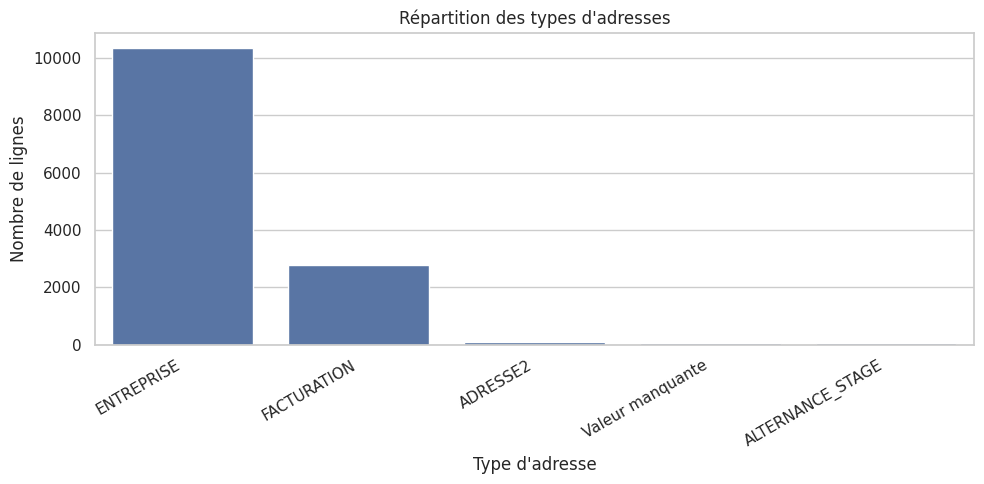

In [11]:
# Analyse de la répartition des types d'adresses

adresse_counts = (
    df["Code.Type d'adresse"]
    .fillna("Valeur manquante")
    .value_counts()
    .reset_index()
)

adresse_counts.columns = ["type_adresse", "nombre_lignes"]

print("Répartition des types d'adresses :")
for _, row in adresse_counts.iterrows():
    print(f"{row['type_adresse']} : {row['nombre_lignes']}")

plt.figure(figsize=(10, 5))
sns.barplot(
    data=adresse_counts,
    x="type_adresse",
    y="nombre_lignes"
)

plt.title("Répartition des types d'adresses")
plt.xlabel("Type d'adresse")
plt.ylabel("Nombre de lignes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### Lecture de la dimension Adresse

La majorité des lignes correspond à des adresses de type `ENTREPRISE`, mais le fichier contient également des adresses de facturation, des adresses secondaires et des adresses liées à l’alternance ou aux stages.

Cette distinction devra être conservée dans l’ETL afin d’éviter de fusionner des adresses qui n’ont pas le même rôle métier. Pour l’intégration, il faudra donc prévoir une structure permettant de rattacher plusieurs adresses typées à une même entité.


### 5.3 Analyse de la dimension Événements et historique de taxe

Cette partie analyse les événements présents dans le fichier, principalement liés aux versements de taxe d’apprentissage. Elle permet également de vérifier que les dates peuvent être converties proprement afin de préparer leur exploitation dans l’ETL.


In [12]:
# Analyse des événements et conversion des dates

taxe_events = df["Code.Type d'événement"].fillna("Valeur manquante").value_counts(dropna=False)

print("Répartition des types d'événements :")
for value, count in taxe_events.items():
    print(f"{value} : {count}")

# Conversion des dates d'événement
# Le fichier contient des dates avec heure et des dates sans heure.

date_with_time = pd.to_datetime(
    df["Début.Événement"],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

date_without_time = pd.to_datetime(
    df["Début.Événement"],
    format="%d/%m/%Y",
    errors="coerce"
)

df["Date_Evenement"] = date_with_time.fillna(date_without_time)
df["Annee_Evenement"] = df["Date_Evenement"].dt.year.astype("Int64")

taxe_mask = df["Code.Type d'événement"].eq("TAXE_VERSEMENT_ENTREPRISE")

nb_lignes_taxe = taxe_mask.sum()
nb_taxe_avec_date = (taxe_mask & df["Date_Evenement"].notna()).sum()
nb_taxe_sans_date = (taxe_mask & df["Date_Evenement"].isna()).sum()

print("\nLignes de taxe recensées :", nb_lignes_taxe)
print("Lignes de taxe avec date exploitable :", nb_taxe_avec_date)
print("Lignes de taxe sans date exploitable :", nb_taxe_sans_date)

annee_distribution = (
    df.loc[taxe_mask, "Annee_Evenement"]
    .dropna()
    .value_counts()
    .sort_index()
)

print("\nDistribution des années de taxe :")
for year, count in annee_distribution.items():
    print(f"{int(year)} : {count}")

Répartition des types d'événements :
Valeur manquante : 8160
TAXE_VERSEMENT_ENTREPRISE : 5185

Lignes de taxe recensées : 5185
Lignes de taxe avec date exploitable : 5185
Lignes de taxe sans date exploitable : 0

Distribution des années de taxe :
2016 : 327
2017 : 393
2018 : 339
2019 : 620
2020 : 502
2021 : 462
2022 : 791
2024 : 387
2025 : 1120
2026 : 244


#### Focus sur les répétitions historiques légitimes liées à la taxe

Pour illustrer les répétitions métier liées à l’historique des versements de taxe, l’analyse ci-dessous s’appuie sur des structures comme **IFREMER** ou **ALE INTERNATIONAL**, qui présentent plusieurs lignes de taxe sur différentes années.


In [14]:
# Exemple de répétitions historiques légitimes sur les événements de taxe

df_ex_taxe = df[
    df["Libellé.Entité"].str.contains("IFREMER|ALE INTERNATIONAL", na=False, case=False)
    & df["Code.Type d'événement"].eq("TAXE_VERSEMENT_ENTREPRISE")
].copy()

cles_evenement_taxe = [
    "Code.Entité",
    "Libellé.Entité",
    "Montant global.Taxe versement",
    "Date_Evenement",
    "Annee_Evenement",
]

df_ex_taxe_distincts = (
    df_ex_taxe[cles_evenement_taxe]
    .dropna(subset=["Montant global.Taxe versement", "Date_Evenement"])
    .drop_duplicates()
    .sort_values(by=["Libellé.Entité", "Date_Evenement"])
)

print("Nombre de lignes brutes taxe dans l'exemple :", len(df_ex_taxe))
print("Nombre d'événements taxe distincts dans l'exemple :", len(df_ex_taxe_distincts))

print("\nÉvénements taxe distincts observés :")
print(
    df_ex_taxe_distincts
    .head(10)
    .to_string(index=False)
)


Nombre de lignes brutes taxe dans l'exemple : 465
Nombre d'événements taxe distincts dans l'exemple : 15

Événements taxe distincts observés :
                               Code.Entité           Libellé.Entité Montant global.Taxe versement      Date_Evenement  Annee_Evenement
              ALCATEL_LUCENT_ENTERPRISE_92        ALE INTERNATIONAL                          4500 2021-05-20 00:00:00             2021
ALCATEL_LUCENT_ENTERPRISE_INTERNATIONAL_29        ALE INTERNATIONAL                       1825,38 2024-01-19 08:00:00             2024
ALCATEL_LUCENT_ENTERPRISE_INTERNATIONAL_29        ALE INTERNATIONAL                       2259,28 2025-03-11 08:00:00             2025
ALCATEL_LUCENT_ENTERPRISE_INTERNATIONAL_29        ALE INTERNATIONAL                       2281,47 2025-12-19 08:00:00             2025
                                IFREMER_29 IFREMER CENTRE  BRETAGNE                          2600 2019-07-22 08:00:00             2019
                                IFREMER_29 IFRE

#### Lecture des répétitions liées à la taxe

L’exemple montre que les lignes de taxe ne doivent pas être interprétées uniquement ligne par ligne.

Certaines répétitions sont légitimes, car une même entité peut avoir plusieurs versements sur plusieurs dates ou années. D’autres répétitions proviennent de la structure plate de l’export : un même événement de taxe peut être répété sur plusieurs lignes lorsqu’il est associé à plusieurs contacts ou à plusieurs informations d’adresse.

Pour l’ETL, les événements de taxe devront donc être dédupliqués avec une clé métier spécifique, par exemple en combinant l’entité, la date de l’événement et le montant du versement. Cette règle permettra de conserver l’historique réel sans multiplier artificiellement les mêmes versements.

### 5.4 Analyse quantitative des montants de taxe

Cette partie vérifie la conversion des montants de taxe d’apprentissage en format numérique. Elle permet également d’identifier le risque de surévaluation lié aux répétitions de lignes dans l’export plat.


In [16]:
# Conversion des montants de taxe en format numérique

df["Montant_Taxe_Decimal"] = (
    df["Montant global.Taxe versement"]
    .astype("string")
    .str.replace(",", ".", regex=False)
    .str.replace(r"\s+", "", regex=True)
)

df["Montant_Taxe_Decimal"] = pd.to_numeric(
    df["Montant_Taxe_Decimal"],
    errors="coerce"
)

taxe_mask = df["Code.Type d'événement"].eq("TAXE_VERSEMENT_ENTREPRISE")

print("Statistiques descriptives des montants de taxe renseignés :")
print(df.loc[taxe_mask, "Montant_Taxe_Decimal"].describe().to_string())

somme_lignes_taxe = df.loc[taxe_mask, "Montant_Taxe_Decimal"].sum()

cles_taxe = [
    "Code.Entité",
    "Date_Evenement",
    "Montant_Taxe_Decimal",
]

taxe_distincte = (
    df.loc[taxe_mask, cles_taxe]
    .dropna(subset=["Date_Evenement", "Montant_Taxe_Decimal"])
    .drop_duplicates()
)

somme_taxe_distincte = taxe_distincte["Montant_Taxe_Decimal"].sum()

print(f"\nSomme brute des montants sur les lignes de taxe : {somme_lignes_taxe:,.2f} €")
print(f"Somme après dédoublonnage indicatif par entité/date/montant : {somme_taxe_distincte:,.2f} €")
print(f"Nombre de lignes de taxe avec montant : {df.loc[taxe_mask, 'Montant_Taxe_Decimal'].notna().sum()}")
print(f"Nombre d'événements taxe distincts estimés : {len(taxe_distincte)}")

Statistiques descriptives des montants de taxe renseignés :
count         5185.0
mean     3172.287595
std      3546.766194
min             0.01
25%            676.0
50%           2000.0
75%           4785.0
max         25621.41

Somme brute des montants sur les lignes de taxe : 16,448,311.18 €
Somme après dédoublonnage indicatif par entité/date/montant : 1,864,394.20 €
Nombre de lignes de taxe avec montant : 5185
Nombre d'événements taxe distincts estimés : 1293


In [18]:
# Exemple de répétition d'un montant de taxe dans l'export plat

df_kyndryl = df[
    df["Libellé.Entité"].str.contains("KYNDRYL", na=False, case=False)
    & taxe_mask
].copy()

print("Nombre de lignes taxe pour KYNDRYL :", len(df_kyndryl))

print("\nAperçu des lignes KYNDRYL :")
print(
    df_kyndryl[
        ["Libellé.Entité", "Montant global.Taxe versement", "Date_Evenement", "Nom.Individu"]
    ]
    .head(8)
    .to_string(index=False)
)

print("\nTop 5 des montants de taxe distincts les plus élevés :")
print(
    df.loc[taxe_mask, ["Libellé.Entité", "Montant_Taxe_Decimal", "Date_Evenement"]]
    .dropna(subset=["Montant_Taxe_Decimal", "Date_Evenement"])
    .drop_duplicates()
    .nlargest(5, "Montant_Taxe_Decimal")
    .to_string(index=False)
)

Nombre de lignes taxe pour KYNDRYL : 48

Aperçu des lignes KYNDRYL :
Libellé.Entité Montant global.Taxe versement      Date_Evenement Nom.Individu
KYNDRYL FRANCE                       4356,42 2025-03-05 08:00:00      RENAULT
KYNDRYL FRANCE                       4356,42 2025-03-05 08:00:00      RENAULT
KYNDRYL FRANCE                      25621,41 2024-01-19 08:00:00      RENAULT
KYNDRYL FRANCE                       10341,6 2022-05-31 00:00:00      RENAULT
KYNDRYL FRANCE                       10341,6 2022-05-31 00:00:00      RENAULT
KYNDRYL FRANCE                       10341,6 2022-05-31 00:00:00      RENAULT
KYNDRYL FRANCE                       4356,42 2025-03-05 08:00:00    RENNESSON
KYNDRYL FRANCE                       4356,42 2025-03-05 08:00:00    RENNESSON

Top 5 des montants de taxe distincts les plus élevés :
       Libellé.Entité  Montant_Taxe_Decimal      Date_Evenement
       KYNDRYL FRANCE              25621.41 2024-01-19 08:00:00
                 NIJI               19830.0 2

#### Lecture des montants de taxe

Les montants de taxe sont correctement convertis en format numérique après remplacement de la virgule décimale.

La somme brute des montants présents dans les lignes de l’export ne doit pas être considérée comme un total financier fiable. Le fichier étant plat, c’est-à-dire organisé comme un export tabulaire unique, il regroupe sur une même ligne des informations de nature différente : entité, adresse, contact et événement de taxe. Ainsi, un même versement peut être répété plusieurs fois lorsqu’il est associé à plusieurs contacts, adresses ou autres informations métier.

Pour l’ETL, les montants de taxe devront donc être rattachés à des événements distincts. Une clé métier indicative peut combiner le code entité, la date de l’événement et le montant du versement. Cette règle permettra de conserver l’historique de taxe tout en limitant la multiplication artificielle des mêmes versements.


### 5.5 Analyse de la dimension Contacts et fonctions

Cette partie analyse les informations disponibles sur les interlocuteurs associés aux entités. Elle permet de distinguer les lignes contenant un contact nominatif des lignes où seule une fonction, une entité ou une adresse est renseignée.


Répartition des fonctions recensées :
DIRECTION_RH : 4952
Valeur manquante : 4412
DIRECTION : 3981

Synthèse des informations de contact :
Lignes avec nom ou prénom renseigné : 8872
Lignes avec fonction renseignée : 8933
Lignes avec nom, prénom et fonction renseignés : 8865


/tmp/ipykernel_56191/823487045.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


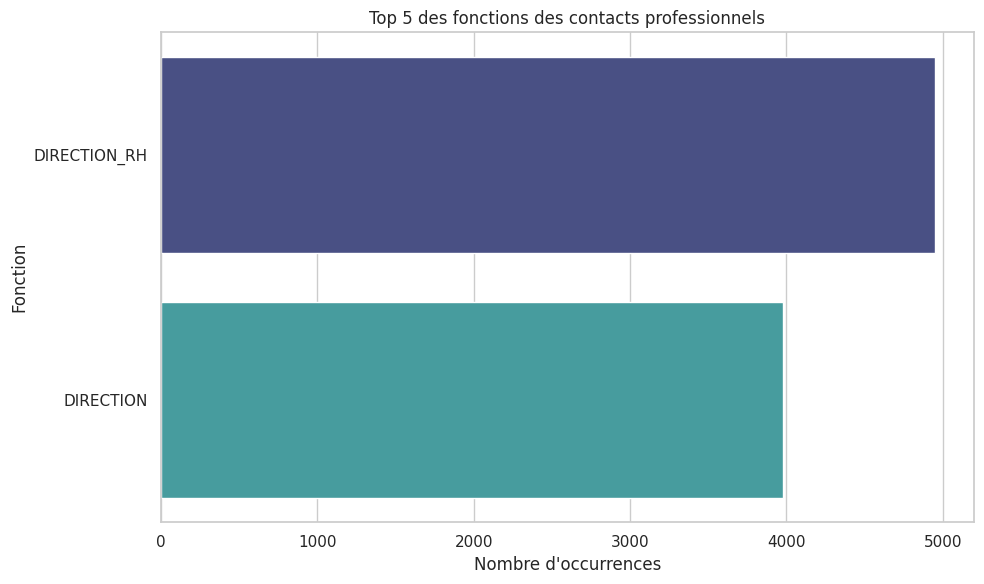

In [20]:
# Analyse des contacts et des fonctions associées

fonctions_contacts = df["Code.Fonctions"].fillna("Valeur manquante").value_counts()

print("Répartition des fonctions recensées :")
for fonction, count in fonctions_contacts.items():
    print(f"{fonction} : {count}")

lignes_avec_contact_nominatif = df[["Nom.Individu", "Prénom.Individu"]].notna().any(axis=1).sum()
lignes_avec_fonction = df["Code.Fonctions"].notna().sum()
lignes_contact_complet = df[["Nom.Individu", "Prénom.Individu", "Code.Fonctions"]].notna().all(axis=1).sum()

print("\nSynthèse des informations de contact :")
print(f"Lignes avec nom ou prénom renseigné : {lignes_avec_contact_nominatif}")
print(f"Lignes avec fonction renseignée : {lignes_avec_fonction}")
print(f"Lignes avec nom, prénom et fonction renseignés : {lignes_contact_complet}")

top_fonctions = df["Code.Fonctions"].dropna().value_counts().head(5)

sns.barplot(
    x=top_fonctions.values,
    y=top_fonctions.index,
    palette="mako"
)

plt.title("Top 5 des fonctions des contacts professionnels")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Fonction")
plt.tight_layout()
plt.show()

#### Lecture de la dimension Contacts et fonctions

Les fonctions renseignées correspondent principalement à des interlocuteurs de direction ou de direction RH. Ces informations sont importantes pour le CRM, car elles permettent de qualifier le rôle des personnes associées aux entités.

Cependant, toutes les lignes ne contiennent pas un contact nominatif complet. Certaines lignes peuvent décrire une entité, une adresse ou un événement sans personne associée.

Pour l’ETL, la création d’un contact devra donc être conditionnée à la présence d’au moins une information nominative exploitable, comme le nom ou le prénom. La fonction pourra ensuite être utilisée comme attribut du contact lorsqu’elle est disponible.


## 6. Analyse des doublons stricts de contenu

Cette partie identifie les lignes strictement identiques après exclusion de la colonne technique `Unnamed: 0`. Ces doublons peuvent être supprimés dans l’ETL, contrairement aux répétitions métier légitimes liées aux contacts, adresses ou événements.


In [22]:
# Analyse des doublons stricts de contenu

df_contenu = df.drop(columns=["Unnamed: 0"], errors="ignore")

total_lignes = len(df)
doublons_stricts = df_contenu.duplicated().sum()
lignes_impliquees_doublons = df_contenu.duplicated(keep=False).sum()
taux_doublons = round((doublons_stricts / total_lignes) * 100, 2)

df_sans_doublons_stricts = df.loc[~df_contenu.duplicated()].copy()

print(f"Volume total de lignes analysées : {total_lignes}")
print(f"Nombre de doublons stricts à supprimer : {doublons_stricts}")
print(f"Nombre de lignes impliquées dans des doublons stricts : {lignes_impliquees_doublons}")
print(f"Taux de doublons stricts : {taux_doublons} %")
print(f"Nombre de lignes après suppression des doublons stricts : {len(df_sans_doublons_stricts)}")

colonnes_exemple_doublons = [
    "Code.Entité",
    "Libellé.Entité",
    "Code.Type d'adresse",
    "Code.Type d'événement",
    "Montant global.Taxe versement",
    "Début.Événement",
    "Nom.Individu",
    "Prénom.Individu",
]

print("\nExemple de lignes impliquées dans des doublons stricts :")
print(
    df.loc[df_contenu.duplicated(keep=False), colonnes_exemple_doublons]
    .head(8)
    .to_string(index=False)
)

Volume total de lignes analysées : 13345
Nombre de doublons stricts à supprimer : 910
Nombre de lignes impliquées dans des doublons stricts : 1623
Taux de doublons stricts : 6.82 %
Nombre de lignes après suppression des doublons stricts : 12435

Exemple de lignes impliquées dans des doublons stricts :
                               Code.Entité    Libellé.Entité Code.Type d'adresse     Code.Type d'événement Montant global.Taxe versement  Début.Événement    Nom.Individu Prénom.Individu
ALCATEL_LUCENT_ENTERPRISE_INTERNATIONAL_29 ALE INTERNATIONAL          ENTREPRISE TAXE_VERSEMENT_ENTREPRISE                       2259,28 11/03/2025 08:00 GIMENEZ-VEYRIER          Karine
ALCATEL_LUCENT_ENTERPRISE_INTERNATIONAL_29 ALE INTERNATIONAL          ENTREPRISE TAXE_VERSEMENT_ENTREPRISE                       2259,28 11/03/2025 08:00 GIMENEZ-VEYRIER          Karine
ALCATEL_LUCENT_ENTERPRISE_INTERNATIONAL_29 ALE INTERNATIONAL          ENTREPRISE TAXE_VERSEMENT_ENTREPRISE                       2259,28 11

#### Lecture des doublons stricts

L’analyse confirme la présence de doublons stricts, c’est-à-dire de lignes entièrement identiques une fois la colonne technique `Unnamed: 0` exclue.

Ces doublons peuvent être supprimés au début de l’ETL, car ils ne portent pas d’information métier supplémentaire. Cette suppression doit toutefois rester limitée aux doublons stricts de contenu.

Les autres répétitions observées dans le fichier ne doivent pas être supprimées automatiquement : elles peuvent correspondre à plusieurs contacts, plusieurs adresses ou plusieurs événements associés à une même entité. L’ETL devra donc distinguer les doublons stricts à supprimer des répétitions métier à restructurer.


## 7. Conclusion finale de l’EDA et synthèse pré-ETL

À la suite de cette analyse exploratoire, le fichier apparaît exploitable pour le POC2, sous réserve d’appliquer plusieurs règles de nettoyage, de conversion et de restructuration dans l’ETL.

1. **Exploitabilité globale :**
   Le fichier peut être exploité à condition d’ignorer les 21 lignes de préambule Aurion (`skiprows=21`) et d’utiliser un encodage adapté à l’export. Le chargement avec `cp1252` permet de mieux gérer certains caractères issus d’un environnement Windows.

2. **Structure multi-dimensionnelle du fichier :**
   Ce fichier ne correspond pas à une simple table d’entreprises. Il s’agit d’un export tabulaire unique qui regroupe des informations de nature différente : entités, adresses, contacts, données de suivi pédagogique et événements de taxe.

3. **Suppression des doublons stricts :**
   Les doublons stricts de contenu, calculés après exclusion de la colonne technique `Unnamed: 0`, pourront être supprimés au début de l’ETL. Cette suppression doit rester limitée aux lignes entièrement identiques.

4. **Conservation des répétitions métier légitimes :**
   Les lignes répétées concernant une même entité ne doivent pas être supprimées automatiquement. Elles peuvent représenter plusieurs contacts, plusieurs adresses ou plusieurs événements associés à une même structure. Ces informations devront être regroupées et restructurées plutôt qu’effacées.

5. **Mapping cible proposé pour le POC2 :**
   L’ETL devra préparer une structure permettant de distinguer les principaux objets métier :

   * **Entité / organisation :** créée une seule fois à partir du `Code.Entité` lorsque celui-ci est disponible ;
   * **Contact :** créé uniquement lorsqu’une information nominative exploitable est présente, puis rattaché à l’organisation correspondante ;
   * **Adresse :** conservée avec son type (`ENTREPRISE`, `FACTURATION`, `ADRESSE2`, `ALTERNANCE_STAGE`) afin de gérer les adresses multiples ;
   * **Historique de taxe :** structuré sous forme d’événements distincts, avec une vigilance particulière sur les répétitions de lignes ;
   * **Suivi pédagogique :** conservé lorsque des informations relatives aux stages, contrats professionnels ou apprentissages sont présentes.

6. **Conversions nécessaires :**
   Les montants de taxe devront être convertis en nombres décimaux afin de permettre les calculs et les contrôles. Les dates d’événement devront également être converties dans un format exploitable pour permettre les analyses temporelles et le requêtage.

7. **Gestion des coordonnées absentes :**
   Les champs `email` et `telephone` ne sont pas présents dans cet export Aurion. La structure cible pourra donc prévoir ces champs avec une valeur nulle, dans l’attente d’un éventuel enrichissement par d’autres sources.

Cette EDA confirme que le fichier peut servir de base au POC2, mais qu’il ne doit pas être intégré ligne par ligne sans transformation. La prochaine étape consiste à construire un ETL capable de nettoyer le fichier, de supprimer uniquement les doublons stricts, de préserver les répétitions métier utiles, puis de produire une structure adaptée au chargement dans MongoDB et à l’affichage dans CremeCRM.
